# Notas de uso para problemas de Linear Matrix Inequalities (LMI)

*(Traducción a Python del livescript `lmi_example.mlx`)*

**Nota importante sobre esta traducción:** el `.mlx` original usa el **LMI Lab** de MATLAB (`setlmis`, `lmivar`, `lmiterm`, `getlmis`, `feasp`, `dec2mat`), una API muy verbosa y específica de MATLAB (hay que definir cada término de cada desigualdad matriz a matriz). **No existe un equivalente directo en Python**, pero no hace ninguna falta: en Python el estándar para plantear y resolver LMIs es la librería [`cvxpy`](https://www.cvxpy.org/), que permite escribir las desigualdades matriciales **directamente en notación matemática** (con el operador `<<` para $\prec$, o "menor o igual en el sentido de matrices definidas"), sin tener que descomponer cada desigualdad en términos como exige `lmiterm`. El resultado es mucho más legible y cercano a como escribiríamos el problema en la pizarra.

En general, un problema LMI puede definirse como,

$$N^TL(X_1,\cdots, X_K)N \prec M^TR(X_1,\cdots, X_K)M$$

donde $X$ representa un conjunto de variables matriciales con una estructura prescrita. $N$ y $M$ reciben el nombre de factores exteriores y $L$ y $R$ son los términos interiores izquierdo y derecho: son matrices simétricas por bloques que definen combinaciones afines entre las variables matriciales. Es muy importante fijarse en que siempre que se plantee una LMI, el término de la izquierda corresponde a la parte menor de la inecuación.

Lo vamos a ver siguiendo el ejemplo de resolver una ecuación de Lyapunov para un sistema lineal.

$$\dot{x} = Ax, \qquad A^TP+PA \prec 0, \qquad P \succ 0$$

Elegimos una matriz $A$ para nuestro sistema que sea Hurwitz, y por tanto debe cumplirse para ella la ecuación de Lyapunov,

$$A = \begin{pmatrix}-3 & 0 & -4 \\ 2 & -3 & 1 \\ 0 & -1 & -3\end{pmatrix}$$

In [1]:
import numpy as np
import cvxpy as cp
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

In [2]:
A = np.array([[-3, 0, -4], [2, -3, 1], [0, -1, -3]])
lam = np.linalg.eigvals(A)
lam

array([-1.1662+0.j    , -3.9169+1.8767j, -3.9169-1.8767j])

Como era de esperar, todos los autovalores tienen parte real negativa: $A$ es Hurwitz.

## Planteamiento del problema con `cvxpy`

En `cvxpy` no hace falta "activar un entorno" como `setlmis([])`, ni definir cada término por separado con `lmiterm`. Simplemente:

1. Declaramos la variable matricial de decisión con `cp.Variable((n, n), symmetric=True)` (el equivalente de `lmivar(1, [3,1])`: una matriz simétrica $3\times 3$).
2. Escribimos las restricciones **tal cual las desigualdades matemáticas**, usando `<<` para $\prec$ ("menor en el sentido semidefinido") y `>>` para $\succ$.
3. Como una LMI estricta ($\prec 0$, sin incluir el igual) no es directamente representable en un solver numérico, añadimos un pequeño margen `eps` para forzar que la solución sea estrictamente definida (esto es el equivalente práctico de que `tmin` salga negativo en `feasp`).

In [3]:
n = A.shape[0]
P = cp.Variable((n, n), symmetric=True)   # variable matricial, equivalente a P = lmivar(1,[3,1])

eps = 1e-4   # margen estricto (evita que el solver de una solucion 'al borde', P=0)
restricciones = [
    A.T @ P + P @ A << -eps * np.eye(n),   # A'P + PA < 0 (estricta)
    P >> eps * np.eye(n)                    # P > 0 (estricta)
]

problema = cp.Problem(cp.Minimize(0), restricciones)   # solo buscamos factibilidad
problema.solve()

print('estado del problema:', problema.status)   # equivalente a comprobar que tmin<0 en feasp

estado del problema: optimal


Al ser un problema de **factibilidad** (no de optimización de verdad), le damos un objetivo trivial `cp.Minimize(0)` — solo nos interesa si existe alguna $P$ que cumpla las restricciones, no minimizar nada en particular. `problema.status == 'optimal'` es el equivalente Python de comprobar que `tmin < 0` en `feasp` de MATLAB.

A diferencia de `dec2mat` en MATLAB (que hay que llamar aparte para extraer la matriz de la solución "en bruto" del solver), en `cvxpy` la solución ya está directamente disponible en `P.value`, como una matriz de `numpy` normal.

In [4]:
p = P.value
print('p =\n', p)
print('eig(p) =', np.linalg.eigvals(p), ' (positivos)')

Qchk = A.T @ p + p @ A
print('eig(A.T@p + p@A) =', np.linalg.eigvals(Qchk), ' (negativos)')

p =
 [[ 0.0001 -0.      0.    ]
 [-0.      0.0001  0.    ]
 [ 0.      0.      0.0001]]
eig(p) = [0.0001 0.0002 0.0001]  (positivos)
eig(A.T@p + p@A) = [-0.0016 -0.0002 -0.0008]  (negativos)


Confirmamos que $P\succ0$ (autovalores positivos) y que $A^TP+PA\prec0$ (autovalores negativos), tal y como exigía el problema.

## Segundo ejemplo: estabilización de un sistema mediante LMI

Veamos ahora un ejemplo que es continuación del problema de la estabilización de un sistema. Si el sistema es estabilizable, debe satisfacer la ecuación,

$$AP+PA^T-BB^T \prec 0$$

Creamos un sistema estabilizable (tomado del ejemplo de `estabilizabilidad.mlx`),

In [5]:
import control as ct

Ai = np.array([[1, 0, -2], [0, -2, 0], [2, 0, 3]])
B  = np.array([[-1, 0], [0, 0], [1, 2]])

rank_ctrb = np.linalg.matrix_rank(ct.ctrb(Ai, B))
rank_ctrb

np.int64(2)

Construimos la matriz $BB^T$ (en `cvxpy`, a diferencia de `lmiterm`, sí podemos meter cualquier expresión directamente en la restricción, así que este paso es solo por claridad, no por necesidad).

In [6]:
Q = B @ B.T
Q

array([[ 1,  0, -1],
       [ 0,  0,  0],
       [-1,  0,  5]])

En `cvxpy`, a diferencia del LMI Lab de MATLAB, **no hace falta "resetear" nada** (no hay equivalente a `clear LMISYS; setlmis([])`): cada `cp.Problem(...)` nuevo es completamente independiente de los anteriores, así que basta con declarar una nueva variable `P`.

In [7]:
n = Ai.shape[0]
P = cp.Variable((n, n), symmetric=True)

restricciones = [
    Ai @ P + P @ Ai.T - Q << -eps * np.eye(n),   # AP + PA' - BB' < 0
    P >> eps * np.eye(n)                          # P > 0
]

problema = cp.Problem(cp.Minimize(0), restricciones)
problema.solve()

print('estado del problema:', problema.status)
p = P.value
p

estado del problema: optimal


array([[0.1536, 0.    , 0.0178],
       [0.    , 0.0001, 0.    ],
       [0.0178, 0.    , 0.6655]])

Ahora podemos emplear la $p$ obtenida para construir un estabilizador por realimentación de estados, $K=\frac{1}{2}B^Tp^{-1}$.

In [8]:
K = B.T @ np.linalg.inv(p) / 2
lAcl = np.linalg.eigvals(Ai - B @ K)
print('K =\n', K)
print('eig(Ai - B@K) =', lAcl)

K =
 [[-3.3534  0.      0.8409]
 [-0.1745 -0.      1.5073]]
eig(Ai - B@K) = [-1.6045+2.4594j -1.6045-2.4594j -2.    +0.j    ]


Y podemos simular nuestro sistema de modo análogo a como hicimos en el ejemplo de estabilización (ver las funciones `U` y `sistema_lineal` al final del notebook).

In [9]:
def U(K, x):
    return -K @ x

def sistema_lineal(t, x, Ufun, A, B):
    u = Ufun(x)
    return A @ x + B @ u

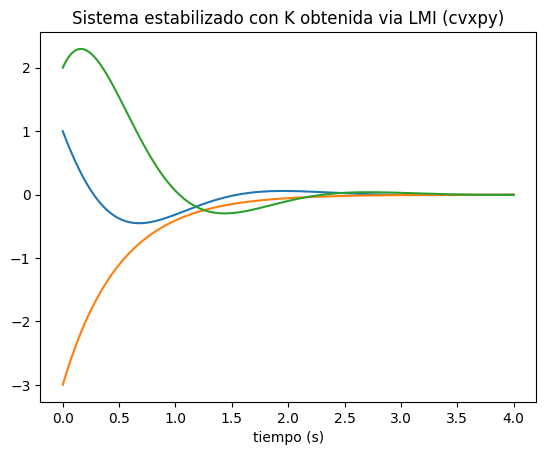

In [10]:
tf = 4
x0 = [1, -3, 2]   # condicion inicial cualquiera

sol = solve_ivp(
    sistema_lineal, [0, tf], x0,
    args=(lambda x: U(K, x), Ai, B),
    max_step=1e-3
)

plt.figure(1)
plt.plot(sol.t, sol.y.T)
plt.xlabel('tiempo (s)')
plt.title('Sistema estabilizado con K obtenida via LMI (cvxpy)')
plt.show()

## Nota final

Los problemas de LMI son en sí mismos todo un campo de estudio. Para saber más de su resolución con `cvxpy`, la [documentación oficial](https://www.cvxpy.org/) tiene buenos ejemplos, incluyendo una sección específica sobre problemas semidefinidos (SDP), que es la categoría a la que pertenecen las LMIs.

**Comparación rápida MATLAB ↔ Python para este tipo de problemas:**

| MATLAB (LMI Lab) | Python (`cvxpy`) |
|---|---|
| `setlmis([])` | (no hace falta, cada `cp.Problem` es independiente) |
| `P = lmivar(1,[3,1])` | `P = cp.Variable((3,3), symmetric=True)` |
| `lmiterm([1,1,1,P], A', 1, 's')` | escribir directamente `A.T @ P + P @ A` |
| `LMISYS = getlmis; feasp(LMISYS)` | `cp.Problem(cp.Minimize(0), restricciones).solve()` |
| `dec2mat(LMISYS, xfeas, P)` | `P.value` |